# Práctica 4: IA en la empresa
## Análisis de Temas en Documentos — BBC News Dataset
 
En esta práctica abordamos el problema del análisis automático de temas (topic analysis) sobre una colección de noticias de prensa en inglés. El objetivo es doble: por un lado, construir un modelo supervisado capaz de clasificar documentos en categorías predefinidas; por otro, explorar la estructura temática latente del corpus mediante técnicas no supervisadas.

El conjunto de datos utilizado proviene del BBC News (años 2004–2005) y es ampliamente conocido en la literatura de procesamiento del lenguaje natural. Contiene 2.225 artículos periodísticos distribuidos en cinco categorías temáticas (business, entertainment, politics, sports y tech).

---

### Estructura de la práctica
1. [Análisis exploratorio de datos (EDA)](#1)
2. [Representación del texto y preprocesamiento](#2)
3. [Tarea 1 - Clasificación supervisada](#3)
4. [Tarea 2 - Modelado de temas (no supervisado)](#4)
5. [Valoración de los resultados](#5)

En primer lugar, se instalarán las dependencias necesarias para el desarrollo de la práctica.

In [1]:
!pip install nltk scikit-learn matplotlib seaborn wordcloud gensim pandas numpy

In [2]:
import os
import zipfile
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

from wordcloud import WordCloud

# Descargar recursos NLTK necesarios
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1. Análisis exploratorio de datos (EDA) <a id='1'></a>

### 1.1. Carga del dataset

El dataset BBC Full Text se distribuye como dos archivos ZIP:
- **`bbc-train.zip`**: 80% de los documentos (conjunto de entrenamiento + validación)
- **`bbc-test.zip`**: 20% de los documentos (conjunto de test independiente)

Cada ZIP contiene carpetas nombradas por categoría y cada documento es un archivo `.txt` con texto en inglés sobre noticias de la BBC (2004-2005).

In [3]:
def load_bbc_from_zip(zip_path):
    """Carga documentos y etiquetas desde un ZIP con estructura categoria/fichero.txt"""
    texts, labels = [], []
    with zipfile.ZipFile(zip_path, 'r') as zf:
        for name in zf.namelist():
            if name.endswith('.txt'):
                parts = name.split('/')
                category = parts[1]  # bbc-train/<categoria>/fichero.txt
                with zf.open(name) as f:
                    text = f.read().decode('utf-8', errors='replace')
                texts.append(text)
                labels.append(category)
    return texts, labels

BASE_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.'
TRAIN_ZIP = os.path.join(BASE_DIR, 'bbc-train.zip')
TEST_ZIP  = os.path.join(BASE_DIR, 'bbc-test.zip')

train_texts, train_labels = load_bbc_from_zip(TRAIN_ZIP)
test_texts,  test_labels  = load_bbc_from_zip(TEST_ZIP)

df_train = pd.DataFrame({'text': train_texts, 'label': train_labels})
df_test  = pd.DataFrame({'text': test_texts,  'label': test_labels})
df_all   = pd.concat([df_train, df_test], ignore_index=True)

print(f"Documentos de entrenamiento : {len(df_train)}")
print(f"Documentos de test          : {len(df_test)}")
print(f"Total documentos            : {len(df_all)}")
print(f"\nClases: {sorted(df_train['label'].unique())}")

Documentos de entrenamiento : 2015
Documentos de test          : 210
Total documentos            : 2225

Clases: ['business', 'entertainment', 'politics', 'sports', 'tech']


### 1.2. Estadísticas básicas del corpus

Antes de construir cualquier modelo, es fundamental entender la distribución de los datos: número de documentos por clase, longitud de los textos y vocabulario.

In [4]:
df_train['n_words'] = df_train['text'].apply(lambda x: len(x.split()))
df_test['n_words']  = df_test['text'].apply(lambda x: len(x.split()))
df_all['n_words']   = df_all['text'].apply(lambda x: len(x.split()))

print("=== Estadísticas de longitud (nº palabras) — conjunto TRAIN ===")
print(df_train.groupby('label')['n_words'].describe().round(1).to_string())
print()
print(f"Media global : {df_train['n_words'].mean():.0f} palabras")
print(f"Mediana      : {df_train['n_words'].median():.0f} palabras")
print(f"Mínimo       : {df_train['n_words'].min()} palabras")
print(f"Máximo       : {df_train['n_words'].max()} palabras")

=== Estadísticas de longitud (nº palabras) — conjunto TRAIN ===
               count   mean    std    min    25%    50%    75%     max
label                                                                 
business       460.0  331.5  139.4  140.0  232.8  299.0  393.5   891.0
entertainment  356.0  336.4  270.8  145.0  226.0  264.0  369.8  3482.0
politics       377.0  447.1  272.1  142.0  320.0  435.0  526.0  4432.0
sports         461.0  331.8  183.3  114.0  207.0  296.0  411.0  1662.0
tech           361.0  503.9  245.2  162.0  337.0  446.0  629.0  2969.0

Media global : 385 palabras
Mediana      : 335 palabras
Mínimo       : 114 palabras
Máximo       : 4432 palabras


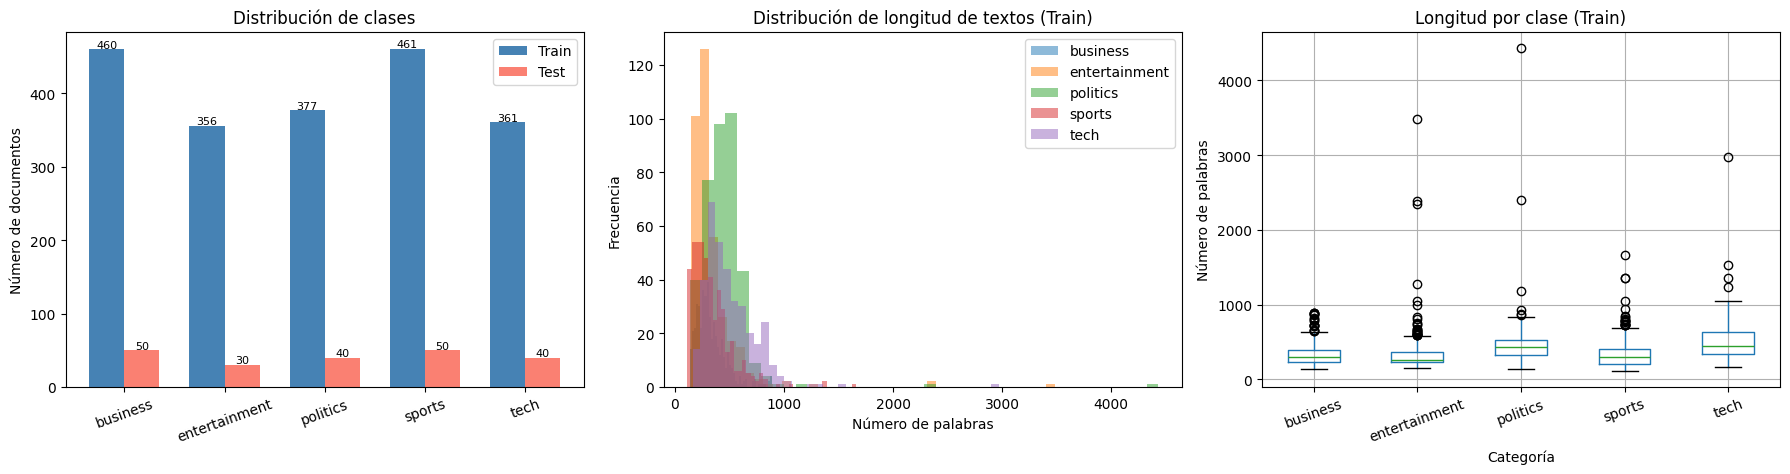

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
PALETTE = 'Set2'

counts_train = df_train['label'].value_counts().sort_index()
counts_test  = df_test['label'].value_counts().sort_index()

x = np.arange(len(counts_train))
width = 0.35
axes[0].bar(x - width/2, counts_train.values, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, counts_test.values,  width, label='Test',  color='salmon')
axes[0].set_xticks(x)
axes[0].set_xticklabels(counts_train.index, rotation=20)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Número de documentos')
axes[0].legend()
for i, (tr, te) in enumerate(zip(counts_train.values, counts_test.values)):
    axes[0].text(i - width/2, tr + 2, str(tr), ha='center', fontsize=8)
    axes[0].text(i + width/2, te + 2, str(te), ha='center', fontsize=8)

for label in df_train['label'].unique():
    axes[1].hist(
        df_train[df_train['label'] == label]['n_words'],
        bins=40, alpha=0.5, label=label
    )
axes[1].set_title('Distribución de longitud de textos (Train)')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

df_train.boxplot(column='n_words', by='label', ax=axes[2])
axes[2].set_title('Longitud por clase (Train)')
axes[2].set_xlabel('Categoría')
axes[2].set_ylabel('Número de palabras')
plt.suptitle('')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.3. Observaciones del análisis exploratorio

- **Balance de clases**: el dataset está razonablemente balanceado entre las 5 categorías, aunque *sport* y *business* tienen ligeramente más documentos. Esto es favorable porque no se necesitan técnicas de rebalanceo.
- **Longitud de textos**: la longitud varía bastante (desde ~100 hasta >1000 palabras). La categoría *tech* tiene los textos más largos de media, mientras que *business* los más cortos. Esta diferencia de longitud puede influir en la representación TF-IDF.
- **Split train/test**: el split es aproximadamente 80/20 por clase, manteniendo la proporción de categorías.

A continuación, se averiguarán cuáles son las palabras más frecuentes por categoría (sin stopwords) para entender el contenido.

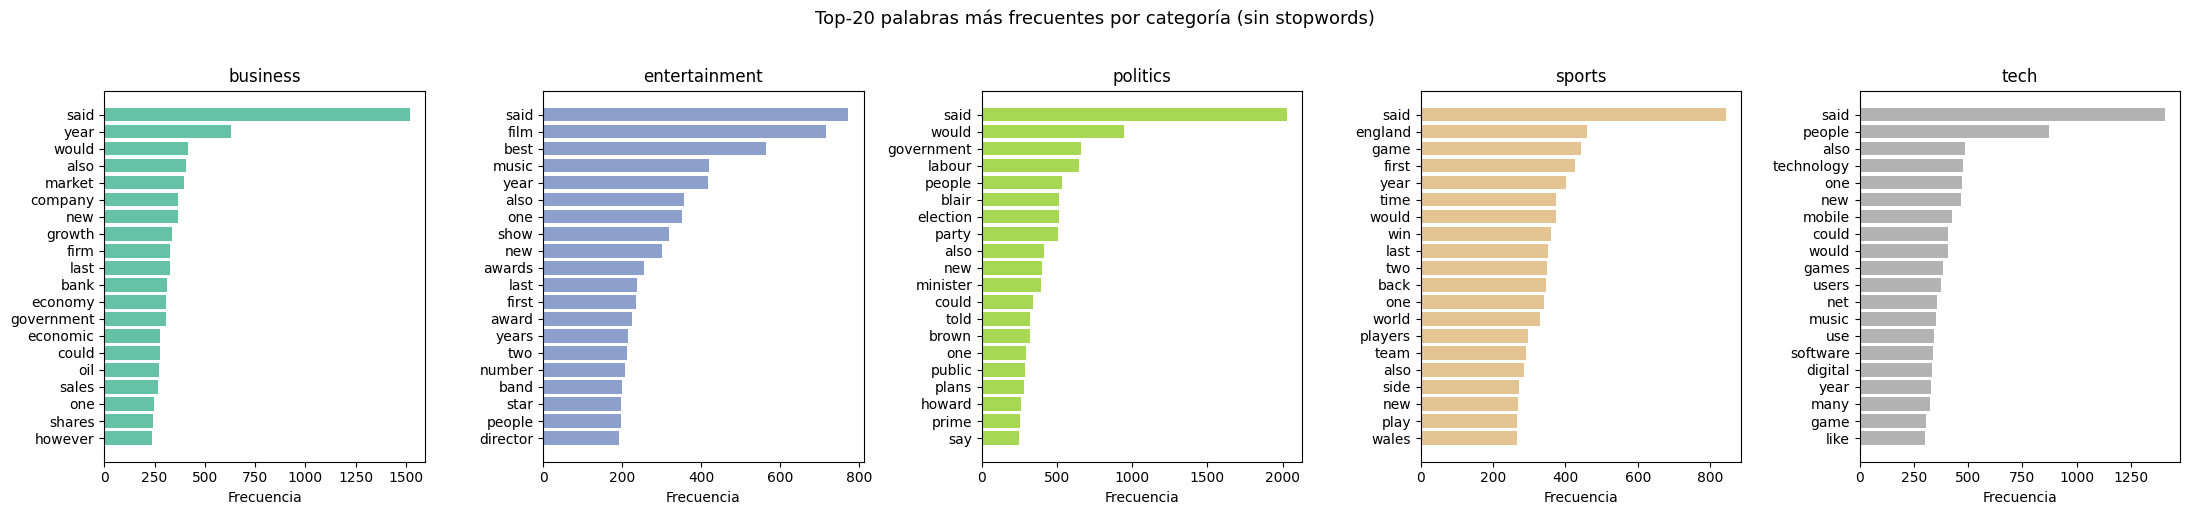

In [6]:
from collections import Counter

stop_en = set(stopwords.words('english'))

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
categories = sorted(df_train['label'].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

for ax, cat, color in zip(axes, categories, colors):
    docs = df_train[df_train['label'] == cat]['text']
    words = []
    for doc in docs:
        tokens = re.findall(r'[a-zA-Z]+', doc.lower())
        words.extend([w for w in tokens if w not in stop_en and len(w) > 2])
    top20 = Counter(words).most_common(20)
    words_top, freqs = zip(*top20)
    ax.barh(list(reversed(words_top)), list(reversed(freqs)), color=color)
    ax.set_title(cat)
    ax.set_xlabel('Frecuencia')

plt.suptitle('Top-20 palabras más frecuentes por categoría (sin stopwords)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('top_words_per_category.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. Representación del texto y preprocesamiento <a id='2'></a>

### 2.1. Estrategia de representación

Para convertir texto en vectores numéricos que los modelos puedan procesar, usaremos **TF-IDF** (*Term Frequency–Inverse Document Frequency*) como representación principal. TF-IDF pondera cada término de forma que:
- Las palabras muy frecuentes **en un documento concreto** reciben mayor peso.
- Las palabras que aparecen en **casi todos los documentos** (p.ej. artículos, preposiciones) se penalizan.

$$\text{TF-IDF}(t, d) = \underbrace{\frac{f_{t,d}}{\sum_k f_{k,d}}}_{\text{TF}} \times \underbrace{\log\frac{N}{|\{d : t \in d\}|}}_{\text{IDF}}$$

donde $N$ es el número total de documentos y $|\{d : t \in d\}|$ el número de documentos que contienen el término $t$.

### 2.2. Pasos de preprocesamiento

El texto en bruto contiene ruido que puede perjudicar la clasificación. Aplicamos los siguientes pasos:

| Paso | Descripción | Motivo |
|------|-------------|--------|
| Minúsculas | Convertir todo a minúsculas | `"Bank"` y `"bank"` son el mismo término |
| Eliminar caracteres especiales | Quitar puntuación y números | Reducen la señal informativa |
| Tokenización | Separar el texto en tokens (palabras) | Unidad básica de análisis |
| Eliminar stopwords | Quitar palabras vacías en inglés | `"the"`, `"is"`, `"at"` no aportan significado temático |
| Lematización | Reducir palabras a su forma base | `"running"` → `"run"`, `"better"` → `"good"` |

Usamos **lematización** (en lugar de stemming) porque produce formas legibles, lo cual es importante para interpretar los resultados del topic modeling.

In [7]:
lemmatizer = WordNetLemmatizer()
stop_en = set(stopwords.words('english'))

def preprocess(text):
    """Pipeline de preprocesamiento de texto."""
    # 1. Minúsculas
    text = text.lower()
    # 2. Eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 3. Tokenizar
    tokens = text.split()
    # 4. Eliminar stopwords y tokens muy cortos
    tokens = [t for t in tokens if t not in stop_en and len(t) > 2]
    # 5. Lematizar
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print("Preprocesando textos de entrenamiento...")
df_train['text_clean'] = df_train['text'].apply(preprocess)
df_test['text_clean']  = df_test['text'].apply(preprocess)
print("Listo.")

idx = 0
print("\n--- Ejemplo de preprocesamiento ---")
print(f"ORIGINAL  : {df_train['text'].iloc[idx][:300]}...")
print(f"PROCESADO : {df_train['text_clean'].iloc[idx][:300]}...")

Preprocesando textos de entrenamiento...
Listo.

--- Ejemplo de preprocesamiento ---
ORIGINAL  : Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and highe...
PROCESADO : sale boost time warner profit quarterly profit medium giant timewarner jumped three month december year earlier firm one biggest investor google benefited sale high speed internet connection higher advert sale timewarner said fourth quarter sale rose profit buoyed one gain offset profit dip warner b...


A continuación, se construirá la representación TF-IDF con los siguientes parámetros:
- `max_features`: limitamos el vocabulario a las 20.000 palabras más informativas.
- `ngram_range` (1,2): incluimos unigramas y bigramas (p.ej. "prime minister").
- `min_df=2`: descartamos términos que aparecen en menos de 2 documentos (ruido).
- `sublinear_tf`: aplica log(1+tf) para suavizar frecuencias muy altas.

In [8]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(df_train['text_clean'])
X_test  = tfidf.transform(df_test['text_clean'])
y_train = df_train['label'].values
y_test  = df_test['label'].values

print(f"Matriz TF-IDF entrenamiento : {X_train.shape}")
print(f"Matriz TF-IDF test          : {X_test.shape}")
print(f"Tamaño del vocabulario      : {len(tfidf.vocabulary_):,} términos")

Matriz TF-IDF entrenamiento : (2015, 20000)
Matriz TF-IDF test          : (210, 20000)
Tamaño del vocabulario      : 20,000 términos


---
## 3. Tarea 1 - Clasificación supervisada <a id='3'></a>

### 3.1. Proceso de refinamiento del modelo

Seguimos un proceso iterativo para seleccionar el mejor clasificador:

1. **Fase 1 - Baseline**: comparamos varios algoritmos con sus parámetros por defecto usando validación cruzada (5-fold) sobre el conjunto de entrenamiento.
2. **Fase 2 - Selección**: elegimos los 2 mejores candidatos y ajustamos hiperparámetros con `GridSearchCV`.
3. **Fase 3 - Evaluación final**: evaluamos el modelo final sobre el conjunto de test independiente.

Como métrica principal se utilizará la *accuracy* (precisión global), adecuada teniendo en cuenta el balance de clases. Complementamos con F1-score macro para capturar posibles asimetrías.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baselines = {
    'Naive Bayes (Multinomial)': MultinomialNB(),
    'Logistic Regression'      : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Linear SVM'               : LinearSVC(random_state=RANDOM_STATE, max_iter=2000),
    'Random Forest'            : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
for name, clf in baselines.items():
    scores = cross_val_score(clf, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:<30}  acc={scores.mean():.4f} ± {scores.std():.4f}")

df_results = pd.DataFrame(results).T
df_results.columns = [f'Fold {i+1}' for i in range(5)]
df_results['Media'] = df_results.mean(axis=1)
df_results['Std']   = df_results.std(axis=1)
print("\nResultados de validación cruzada (5-fold):")
print(df_results[['Media', 'Std']].sort_values('Media', ascending=False).round(4))

Naive Bayes (Multinomial)       acc=0.9702 ± 0.0090
Logistic Regression             acc=0.9801 ± 0.0087
Linear SVM                      acc=0.9816 ± 0.0071
Random Forest                   acc=0.9658 ± 0.0096

Resultados de validación cruzada (5-fold):
                            Media     Std
Linear SVM                 0.9816  0.0071
Logistic Regression        0.9801  0.0087
Naive Bayes (Multinomial)  0.9702  0.0090
Random Forest              0.9658  0.0096


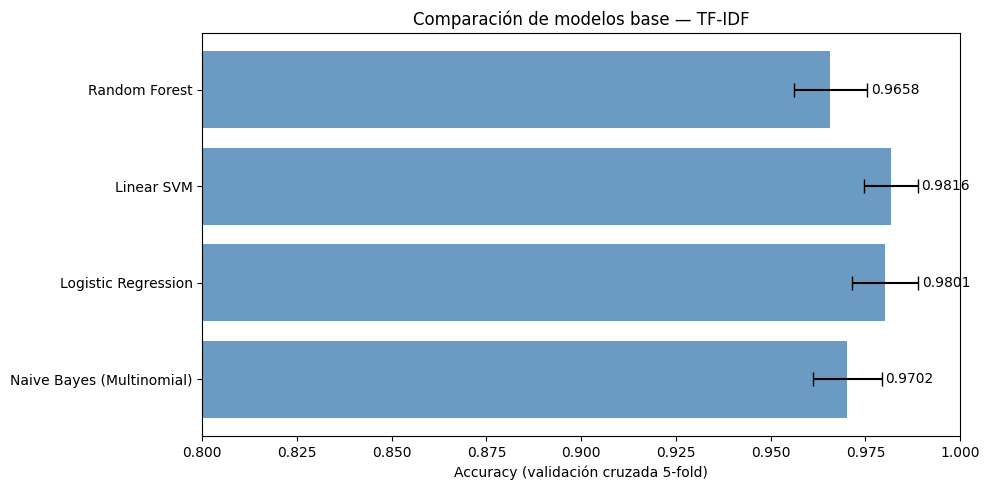

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(results.keys())
medias = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]

bars = ax.barh(names, medias, xerr=stds, capsize=5, color='steelblue', alpha=0.8)
ax.set_xlabel('Accuracy (validación cruzada 5-fold)')
ax.set_title('Comparación de modelos base — TF-IDF')
ax.set_xlim(0.8, 1.0)
for bar, val, std in zip(bars, medias, stds):
    ax.text(val + std + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.2 Refinamiento: búsqueda de hiperparámetros

Los dos mejores modelos en la fase de baseline son típicamente **Linear SVM** y **Logistic Regression** en tareas de clasificación de texto con TF-IDF. Ajustamos el hiperparámetro de regularización `C` para ambos.

- **Linear SVM** (`LinearSVC`): `C` controla el margen de separación. Valores grandes implican márgenes más estrechos (mayor riesgo de sobreajuste).
- **Logistic Regression**: `C` es la inversa de la fuerza de regularización. Un `C` pequeño implica una mayor regularización.

=== Linear SVM — GridSearchCV ===
Mejor C          : 5.0
Mejor accuracy CV: 0.9846


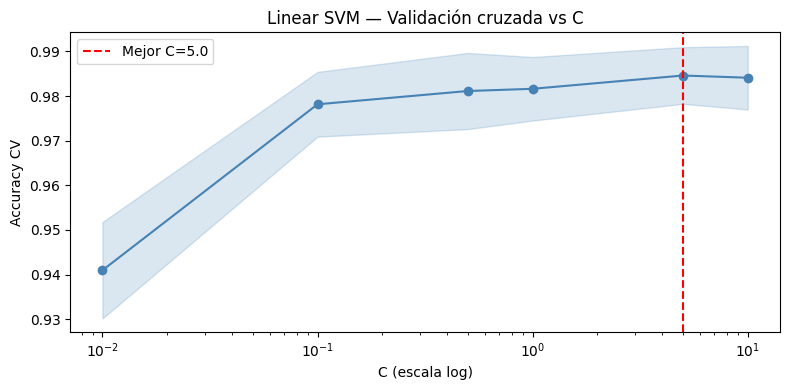

In [11]:
param_grid_svm = {'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_svm = GridSearchCV(
    LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
    param_grid_svm,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_svm.fit(X_train, y_train)

print("=== Linear SVM — GridSearchCV ===")
print(f"Mejor C          : {grid_svm.best_params_['C']}")
print(f"Mejor accuracy CV: {grid_svm.best_score_:.4f}")

cv_df_svm = pd.DataFrame(grid_svm.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(cv_df_svm['param_C'].astype(float), cv_df_svm['mean_test_score'], 'o-', color='steelblue')
plt.fill_between(
    cv_df_svm['param_C'].astype(float),
    cv_df_svm['mean_test_score'] - cv_df_svm['std_test_score'],
    cv_df_svm['mean_test_score'] + cv_df_svm['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.xscale('log')
plt.axvline(grid_svm.best_params_['C'], color='red', linestyle='--', label=f"Mejor C={grid_svm.best_params_['C']}")
plt.xlabel('C (escala log)')
plt.ylabel('Accuracy CV')
plt.title('Linear SVM — Validación cruzada vs C')
plt.legend()
plt.tight_layout()
plt.savefig('svm_grid_search.png', dpi=120, bbox_inches='tight')
plt.show()

=== Logistic Regression — GridSearchCV ===
Mejor C          : 10.0
Mejor accuracy CV: 0.9826


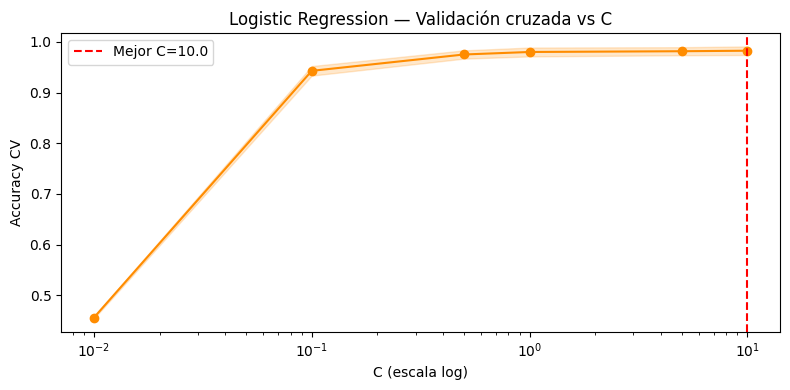


=== Comparativa final de CV ===
Linear SVM (C=5.0)     : 0.9846
Logistic Reg (C=10.0)   : 0.9826


In [12]:
param_grid_lr = {'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs'),
    param_grid_lr,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("=== Logistic Regression — GridSearchCV ===")
print(f"Mejor C          : {grid_lr.best_params_['C']}")
print(f"Mejor accuracy CV: {grid_lr.best_score_:.4f}")

cv_df_lr = pd.DataFrame(grid_lr.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(cv_df_lr['param_C'].astype(float), cv_df_lr['mean_test_score'], 'o-', color='darkorange')
plt.fill_between(
    cv_df_lr['param_C'].astype(float),
    cv_df_lr['mean_test_score'] - cv_df_lr['std_test_score'],
    cv_df_lr['mean_test_score'] + cv_df_lr['std_test_score'],
    alpha=0.2, color='darkorange'
)
plt.xscale('log')
plt.axvline(grid_lr.best_params_['C'], color='red', linestyle='--', label=f"Mejor C={grid_lr.best_params_['C']}")
plt.xlabel('C (escala log)')
plt.ylabel('Accuracy CV')
plt.title('Logistic Regression — Validación cruzada vs C')
plt.legend()
plt.tight_layout()
plt.savefig('lr_grid_search.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n=== Comparativa final de CV ===")
print(f"Linear SVM (C={grid_svm.best_params_['C']})     : {grid_svm.best_score_:.4f}")
print(f"Logistic Reg (C={grid_lr.best_params_['C']})   : {grid_lr.best_score_:.4f}")

### 3.3 Modelo final y evaluación sobre el conjunto de test

Una vez identificado el modelo con mayor accuracy en validación cruzada, lo reentrenamos utilizando la totalidad de los datos de entrenamiento para maximizar la información disponible antes de la evaluación final. A continuación, lo evaluamos sobre el conjunto de test independiente (el 20% de documentos reservados desde el inicio y no vistos en ninguna fase del desarrollo), lo que garantiza una estimación realista y sin sesgos del rendimiento en producción.

Reportamos tres métricas complementarias: la accuracy como indicador global de acierto, el precision, recall y F1 por clase para analizar el rendimiento en cada categoría de forma individual (especialmente relevante ante posibles desequilibrios entre clases) y la matriz de confusión, que permite identificar visualmente qué pares de categorías generan mayor confusión al modelo. La combinación de estas métricas ofrece una visión más completa que cualquier valor agregado por sí solo.

In [13]:
best_model = grid_svm.best_estimator_ if grid_svm.best_score_ >= grid_lr.best_score_ else grid_lr.best_estimator_
model_name = 'Linear SVM' if grid_svm.best_score_ >= grid_lr.best_score_ else 'Logistic Regression'

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print(f"=== Modelo final: {model_name} ===")
print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score macro  : {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print("Informe completo de clasificación:")
print(classification_report(y_test, y_pred))

=== Modelo final: Linear SVM ===
Accuracy en test: 0.9952
F1-score macro  : 0.9946

Informe completo de clasificación:
               precision    recall  f1-score   support

     business       0.98      1.00      0.99        50
entertainment       1.00      0.97      0.98        30
     politics       1.00      1.00      1.00        40
       sports       1.00      1.00      1.00        50
         tech       1.00      1.00      1.00        40

     accuracy                           1.00       210
    macro avg       1.00      0.99      0.99       210
 weighted avg       1.00      1.00      1.00       210



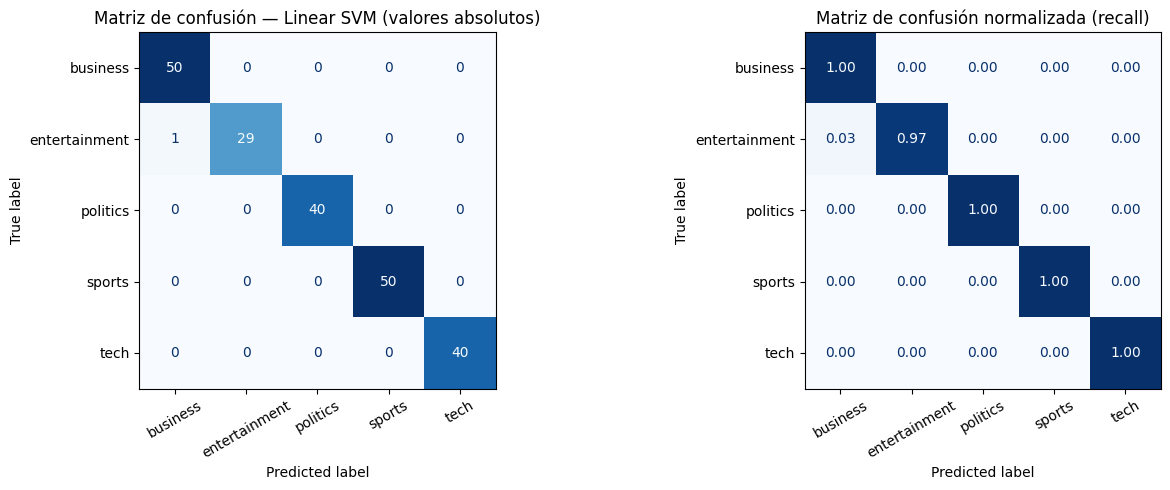

In [14]:
classes = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valores absolutos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de confusión — {model_name} (valores absolutos)')
axes[0].tick_params(axis='x', rotation=30)

# Normalizada (por fila = recall por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=classes)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('Matriz de confusión normalizada (recall)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.4 Análisis detallado de la validación cruzada

Para ser rigurosos, también mostramos los resultados de la validación cruzada desagregados por métrica (accuracy, F1 macro, F1 weighted) con el modelo final.

In [15]:
scoring = {
    'accuracy'   : 'accuracy',
    'f1_macro'   : 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

cv_detailed = cross_validate(
    best_model, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

print("=== Validación cruzada 5-fold — Modelo final ===")
for metric in ['accuracy', 'f1_macro', 'f1_weighted']:
    vals = cv_detailed[f'test_{metric}']
    print(f"  {metric:<15} : {vals.mean():.4f} ± {vals.std():.4f}   (folds: {np.round(vals,4)})")

=== Validación cruzada 5-fold — Modelo final ===
  accuracy        : 0.9846 ± 0.0064   (folds: [0.9901 0.9851 0.9752 0.9926 0.9801])
  f1_macro        : 0.9845 ± 0.0065   (folds: [0.9896 0.9853 0.9746 0.9926 0.9802])
  f1_weighted     : 0.9846 ± 0.0064   (folds: [0.9901 0.985  0.9752 0.9925 0.9801])


---
## 4. Tarea 2 - Modelado de temas (Topic Modeling, no supervisado) <a id='4'></a>

### 4.1 Introducción y motivación

El **modelado de temas** busca descubrir automáticamente los temas latentes en una colección de documentos, **sin usar las etiquetas**. Trabajamos con la colección completa (train + test) para obtener una visión más completa.

Probaremos dos aproximaciones:

| Método | Descripción |
|--------|-------------|
| **LDA** (Latent Dirichlet Allocation) | Modelo probabilístico generativo. Asume que cada documento es una mezcla de temas, y cada tema es una distribución sobre palabras. |
| **K-Means sobre TF-IDF** | Agrupa documentos por similitud coseno en el espacio TF-IDF. Es más simple pero sirve de referencia. |

El número de temas **K** es un hiperparámetro a elegir. Dado que sabemos que hay 5 categorías reales, exploraremos K ∈ {4, 5, 6, 7} para ver si el modelo las redescubre.

Tras aplicar el preprocesamiento a todos los documentos, construimos dos representaciones vectoriales distintas, cada una adaptada al algoritmo que la consume.

Para LDA empleamos una matriz de frecuencias brutas mediante CountVectorizer, ya que este modelo probabilístico se basa en conteos de palabras para estimar las distribuciones temáticas. Para K-Means utilizamos en cambio una representación TF-IDF con escala logarítmica (`sublinear_tf=True`), que penaliza los términos muy frecuentes y da más peso a las palabras discriminativas, lo cual favorece la separación geométrica entre clusters.

En ambos casos aplicamos los mismos criterios de filtrado del vocabulario: un máximo de 15.000 términos, descartando aquellos que aparecen en menos de 3 documentos (ruido y erratas) o en más del 90% del corpus (términos demasiado genéricos para ser informativos), y limitando el análisis a unigramas.

In [16]:
df_all['text_clean'] = df_all['text'].apply(preprocess)

count_vec = CountVectorizer(
    max_features=15000,
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 1)
)
X_count_all = count_vec.fit_transform(df_all['text_clean'])

tfidf_all = TfidfVectorizer(
    max_features=15000,
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)
X_tfidf_all = tfidf_all.fit_transform(df_all['text_clean'])

print(f"Total documentos: {X_count_all.shape[0]}")
print(f"Vocabulario (Count): {X_count_all.shape[1]:,}")
print(f"Vocabulario (TF-IDF): {X_tfidf_all.shape[1]:,}")

Total documentos: 2225
Vocabulario (Count): 11,073
Vocabulario (TF-IDF): 11,073


Entrenamos LDA con 5 temas (coincidiendo con las clases originales del dataset) usando aprendizaje online durante 30 iteraciones, y evaluamos la calidad del modelo mediante la log-verosimilitud y la perplejidad sobre el corpus completo; a continuación extraemos los 15 términos más representativos de cada tema para interpretar su contenido semántico.

In [17]:
N_TOPICS = 5

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=30,
    learning_method='online',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lda.fit(X_count_all)

print(f"LDA entrenado con {N_TOPICS} temas.")
print(f"Log-verosimilitud: {lda.score(X_count_all):.1f}")
print(f"Perplejidad      : {lda.perplexity(X_count_all):.1f}")

feature_names = count_vec.get_feature_names_out()
N_TOP_WORDS = 15

print("\n=== Términos más relevantes por tema (LDA) ===")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-N_TOP_WORDS - 1:-1]]
    print(f"  Tema {topic_idx+1}: {', '.join(top_words)}")

LDA entrenado con 5 temas.
Log-verosimilitud: -3516703.6
Perplejidad      : 2479.6

=== Términos más relevantes por tema (LDA) ===
  Tema 1: said, company, would, year, firm, new, also, deal, share, group, court, sale, executive, told, last
  Tema 2: film, year, best, award, said, show, one, also, star, music, new, first, top, number, last
  Tema 3: said, people, mobile, game, phone, technology, service, one, new, also, user, could, year, computer, would
  Tema 4: said, would, government, year, labour, party, election, people, minister, say, blair, also, could, new, tory
  Tema 5: game, said, year, win, first, player, england, time, back, match, world, two, final, last, second


Para justificar la elección del número de temas, entrenamos LDA con valores de K entre 3 y 8 y comparamos la perplejidad resultante, seleccionando aquel K que minimice dicha métrica sobre el corpus completo.

K=3  ->  Perplejidad=2692.8
K=4  ->  Perplejidad=2632.3
K=5  ->  Perplejidad=2510.9
K=6  ->  Perplejidad=2471.2
K=7  ->  Perplejidad=2487.7
K=8  ->  Perplejidad=2423.7


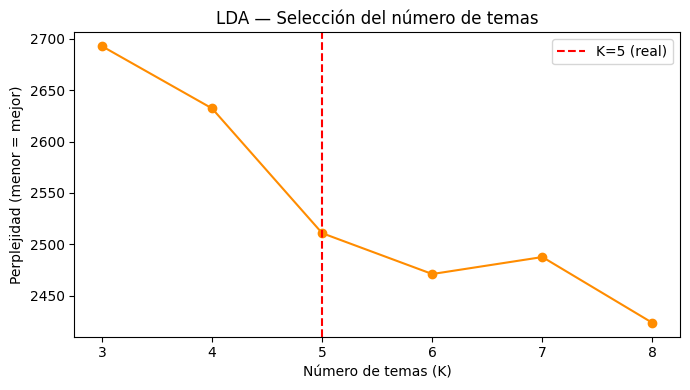

In [18]:
k_range = [3, 4, 5, 6, 7, 8]
perplexities = []

for k in k_range:
    lda_k = LatentDirichletAllocation(
        n_components=k, max_iter=20,
        learning_method='online',
        random_state=RANDOM_STATE
    )
    lda_k.fit(X_count_all)
    perplexities.append(lda_k.perplexity(X_count_all))
    print(f"K={k}  ->  Perplejidad={perplexities[-1]:.1f}")

plt.figure(figsize=(7, 4))
plt.plot(k_range, perplexities, 'o-', color='darkorange')
plt.axvline(5, color='red', linestyle='--', label='K=5 (real)')
plt.xlabel('Número de temas (K)')
plt.ylabel('Perplejidad (menor = mejor)')
plt.title('LDA — Selección del número de temas')
plt.legend()
plt.tight_layout()
plt.savefig('lda_perplexity.png', dpi=120, bbox_inches='tight')
plt.show()

Para facilitar la interpretación de cada tema, generamos nubes de palabras a partir de los pesos asignados por LDA a los 60 términos más relevantes de cada componente, usando una paleta de colores distinta por tema para favorecer la distinción visual.

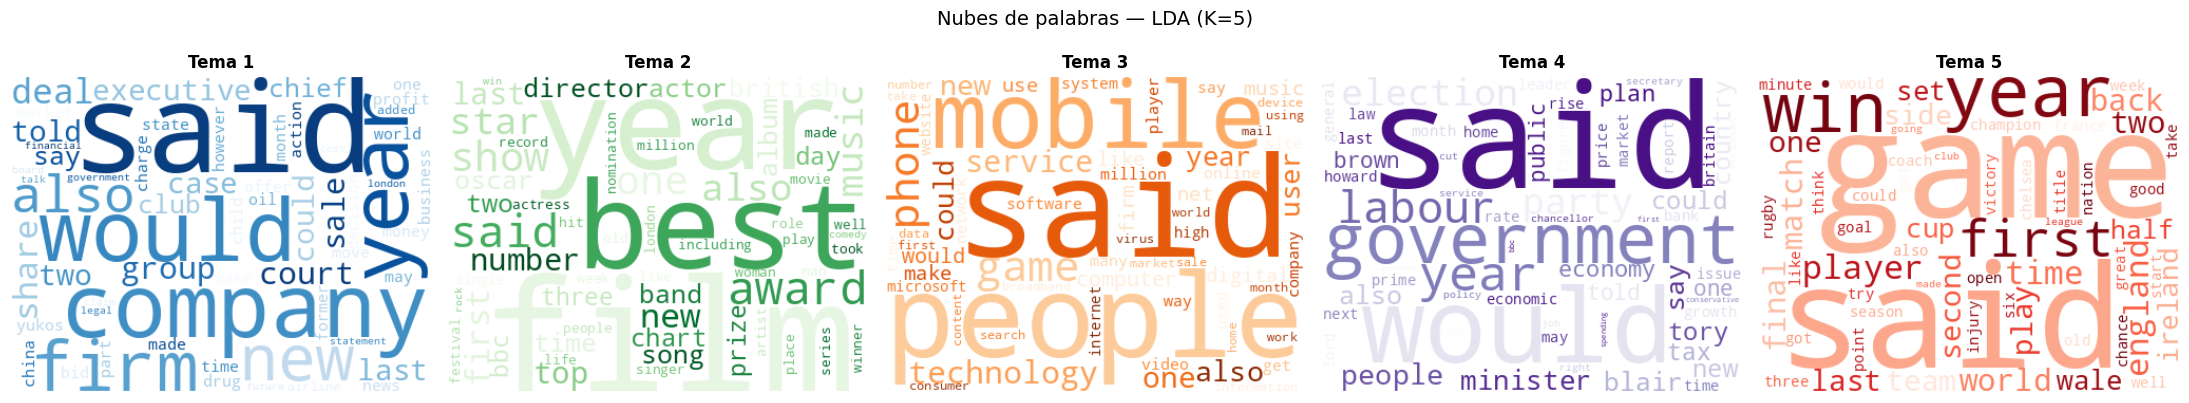

In [19]:
topic_labels = ['Tema 1', 'Tema 2', 'Tema 3', 'Tema 4', 'Tema 5']

fig, axes = plt.subplots(1, N_TOPICS, figsize=(22, 4))
colormap_list = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds']

for topic_idx, (ax, cmap) in enumerate(zip(axes, colormap_list)):
    topic = lda.components_[topic_idx]
    # Creamos un dict {palabra: peso} con las top-100 palabras
    word_weights = {feature_names[i]: topic[i]
                    for i in topic.argsort()[:-101:-1]}
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap=cmap,
        max_words=60
    ).generate_from_frequencies(word_weights)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(topic_labels[topic_idx], fontsize=12, fontweight='bold')

plt.suptitle('Nubes de palabras — LDA (K=5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lda_wordclouds.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 Clustering con K-Means

Como segundo enfoque no supervisado, aplicamos **K-Means** sobre la representación TF-IDF del corpus completo. Dado que trabajamos en un espacio de alta dimensionalidad, aplicamos previamente una reducción dimensional mediante **SVD truncado** (LSA), lo que mejora la calidad de los clusters al eliminar ruido y reduce el coste computacional del algoritmo.

Para evaluar los resultados empleamos métricas de dos naturalezas distintas. Sin hacer uso de las etiquetas, utilizamos el **Silhouette score**, que mide la cohesión interna de cada cluster y su separación respecto al resto (rango de -1 a 1, donde valores más altos indican clusters más compactos y bien diferenciados). Como contraste, y aprovechando que disponemos de etiquetas reales, evaluamos también la correspondencia entre los clusters obtenidos y las categorías originales mediante el **Adjusted Rand Index (ARI)** y la **Normalized Mutual Information (NMI)**, ambos indicadores de hasta qué punto la estructura descubierta de forma no supervisada refleja la organización temática real del corpus.

Así pues, en primer lugar, proyectamos el corpus a 100 componentes LSA y entrenamos K-Means con K=5 y 20 inicializaciones aleatorias para minimizar el riesgo de convergencia a un mínimo local, evaluando el resultado tanto de forma intrínseca con el Silhouette score como de forma extrínseca comparando los clusters obtenidos con las etiquetas reales.

In [20]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_lsa = svd.fit_transform(X_tfidf_all)
print(f"Varianza explicada por {N_COMPONENTS} componentes SVD: {svd.explained_variance_ratio_.sum():.2%}")

kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(X_lsa)

true_labels = df_all['label'].values
le = LabelEncoder()
true_labels_enc = le.fit_transform(true_labels)

sil = silhouette_score(X_lsa, cluster_labels, sample_size=500, random_state=RANDOM_STATE)
ari = adjusted_rand_score(true_labels_enc, cluster_labels)
nmi = normalized_mutual_info_score(true_labels_enc, cluster_labels)

print(f"\n=== K-Means (K=5) — métricas de clustering ===")
print(f"Silhouette Score : {sil:.4f}  (sin etiquetas)")
print(f"Adjusted Rand    : {ari:.4f}  (vs etiquetas reales)")
print(f"NMI              : {nmi:.4f}  (vs etiquetas reales)")

Varianza explicada por 100 componentes SVD: 22.35%

=== K-Means (K=5) — métricas de clustering ===
Silhouette Score : 0.0462  (sin etiquetas)
Adjusted Rand    : 0.9168  (vs etiquetas reales)
NMI              : 0.8848  (vs etiquetas reales)


De forma análoga al análisis de perplejidad en LDA, buscamos el número óptimo de clusters para K-Means combinando el método del codo sobre la inercia y el Silhouette score, evaluando valores de K entre 2 y 10.

K=2  inertia=459.3  silhouette=0.0407
K=3  inertia=444.4  silhouette=0.0562
K=4  inertia=429.7  silhouette=0.0558
K=5  inertia=416.5  silhouette=0.0506
K=6  inertia=408.5  silhouette=0.0480
K=7  inertia=400.6  silhouette=0.0532
K=8  inertia=395.1  silhouette=0.0450
K=9  inertia=387.5  silhouette=0.0631


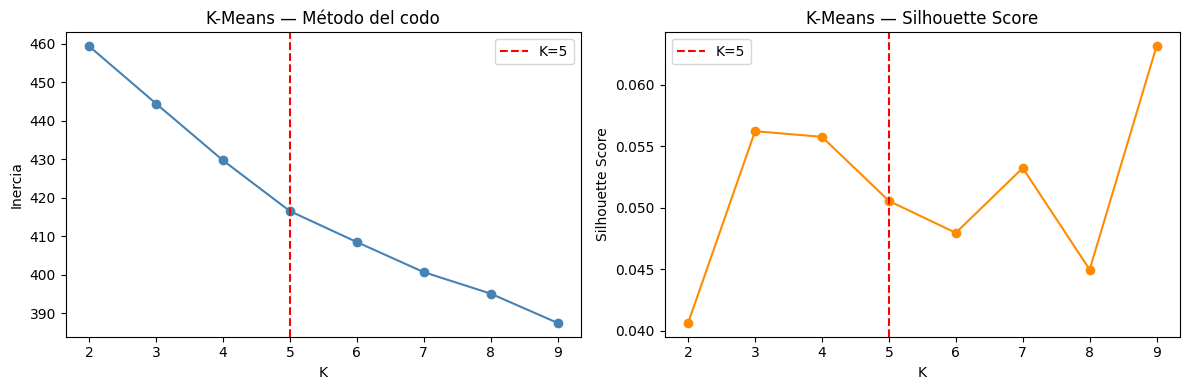

In [21]:
k_range = range(2, 10)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_lsa)
    inertias.append(km.inertia_)
    sil_k = silhouette_score(X_lsa, labels_k, sample_size=500, random_state=RANDOM_STATE)
    silhouettes.append(sil_k)
    print(f"K={k}  inertia={km.inertia_:.1f}  silhouette={sil_k:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].axvline(5, color='red', linestyle='--', label='K=5')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inercia')
axes[0].set_title('K-Means — Método del codo')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, 'o-', color='darkorange')
axes[1].axvline(5, color='red', linestyle='--', label='K=5')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means — Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=120, bbox_inches='tight')
plt.show()

Para visualizar la estructura del clustering en dos dimensiones, aplicamos t-SNE sobre una muestra de 800 documentos y representamos en paralelo los clusters asignados por K-Means y las clases reales, lo que permite comparar visualmente hasta qué punto ambas agrupaciones coinciden en el espacio latente.

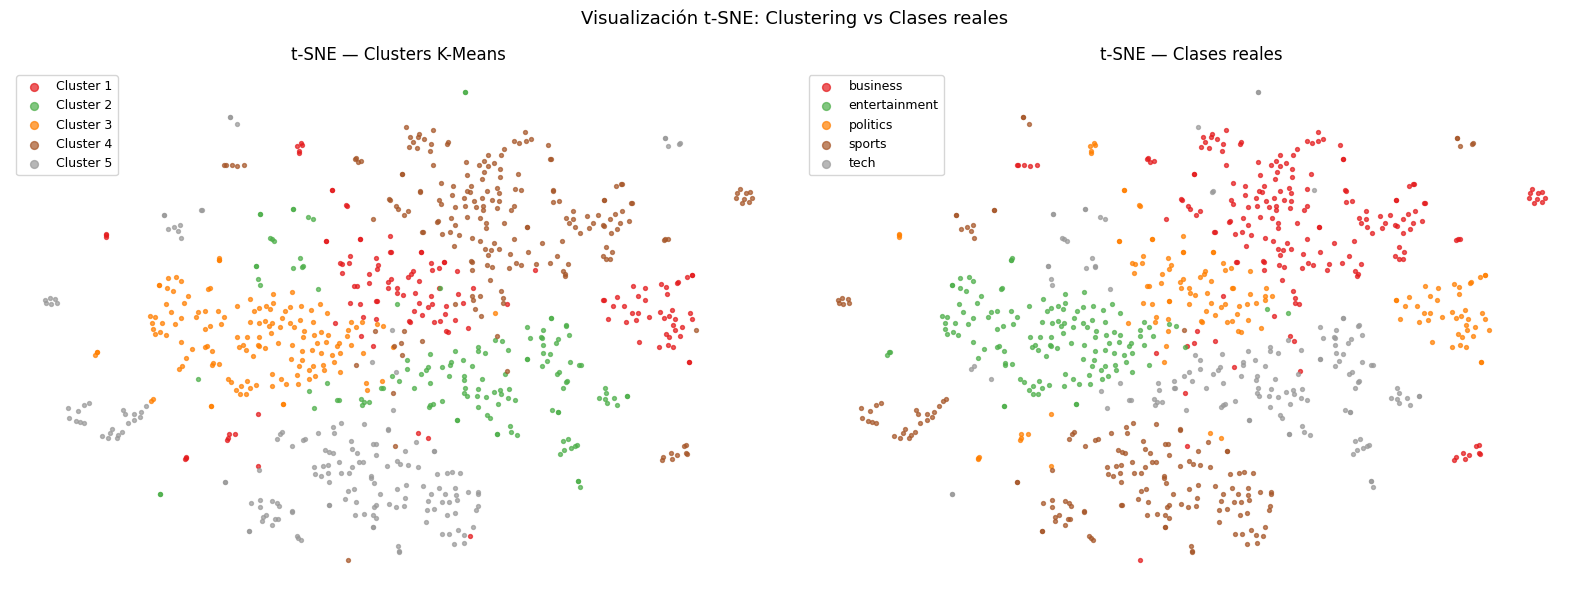

In [22]:
SAMPLE = min(800, len(X_lsa))
idx_sample = np.random.choice(len(X_lsa), SAMPLE, replace=False)
X_sample = X_lsa[idx_sample]
labels_sample  = cluster_labels[idx_sample]
true_sample    = true_labels[idx_sample]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=40, max_iter=1000)
X_2d = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = plt.cm.Set1(np.linspace(0, 1, 5))

# Clusters K-Means
for k in range(5):
    mask = labels_sample == k
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[palette[k]], s=8, alpha=0.7, label=f'Cluster {k+1}')
axes[0].set_title('t-SNE — Clusters K-Means')
axes[0].legend(markerscale=2, fontsize=9)
axes[0].axis('off')

# Clases reales
classes_unique = sorted(np.unique(true_sample))
for i, cls in enumerate(classes_unique):
    mask = true_sample == cls
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[palette[i]], s=8, alpha=0.7, label=cls)
axes[1].set_title('t-SNE — Clases reales')
axes[1].legend(markerscale=2, fontsize=9)
axes[1].axis('off')

plt.suptitle('Visualización t-SNE: Clustering vs Clases reales', fontsize=13)
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

Para interpretar temáticamente cada cluster, generamos nubes de palabras agregando los vectores TF-IDF de todos los documentos pertenecientes a cada grupo y extrayendo los 60 términos con mayor peso acumulado, lo que permite identificar de forma intuitiva el tema dominante en cada cluster.

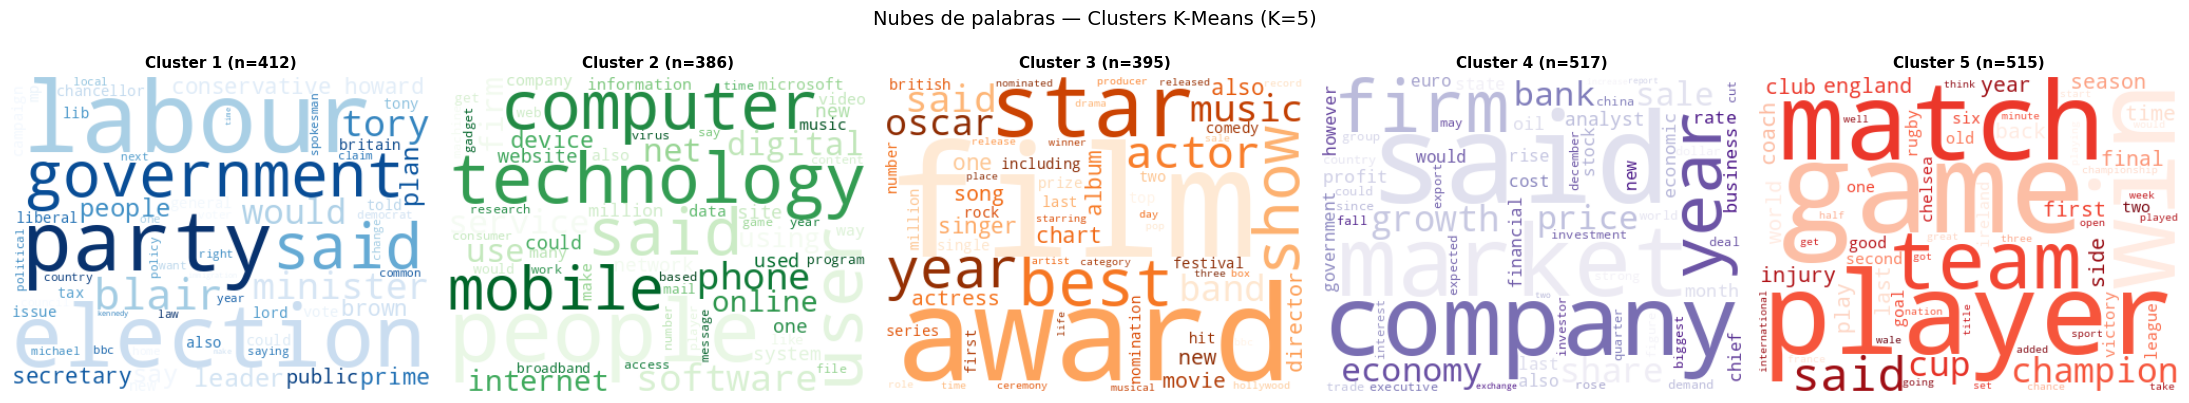

In [23]:
vocab = np.array(tfidf_all.get_feature_names_out())
X_tfidf_dense_sample = X_tfidf_all  # sparse matrix, sin convertir a denso completo

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
colormap_list = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds']

for k, (ax, cmap) in enumerate(zip(axes, colormap_list)):
    # Documentos de este cluster
    doc_indices = np.where(cluster_labels == k)[0]
    # Suma de vectores TF-IDF
    cluster_tfidf = np.asarray(X_tfidf_all[doc_indices].sum(axis=0)).flatten()
    # Top-60 palabras
    top_indices = cluster_tfidf.argsort()[:-61:-1]
    word_weights = {vocab[i]: float(cluster_tfidf[i]) for i in top_indices}

    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap=cmap,
        max_words=60
    ).generate_from_frequencies(word_weights)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Cluster {k+1} (n={len(doc_indices)})', fontsize=11, fontweight='bold')

plt.suptitle('Nubes de palabras — Clusters K-Means (K=5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('kmeans_wordclouds.png', dpi=120, bbox_inches='tight')
plt.show()

Complementamos el análisis visual analizando la composición interna de cada cluster mediante un mapa de calor que muestra la distribución porcentual de las clases reales dentro de cada grupo, lo que nos permite evaluar cuantitativamente la pureza de los clusters y confirmar qué categoría temática predomina en cada uno.

=== Composición de cada cluster (% por clase real) ===
label    business  entertainment  politics  sports  tech
cluster                                                 
0             2.7            0.5      96.1     0.2   0.5
1             1.3            0.8       1.0     0.0  96.9
2             0.3           95.4       1.0     0.5   2.8
3            95.4            0.8       2.1     0.2   1.5
4             0.0            0.0       0.4    98.4   1.2


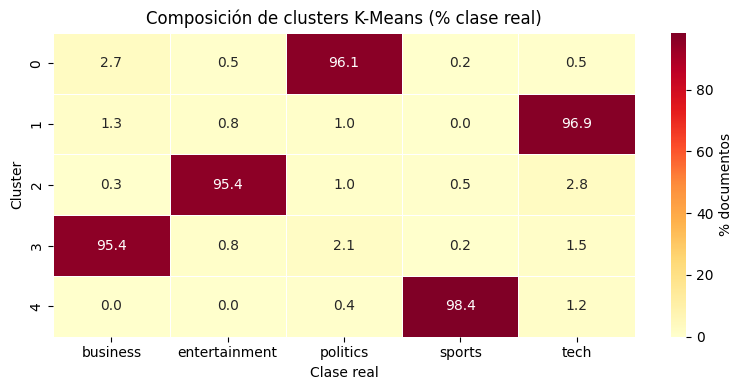

In [24]:
df_all_analysis = df_all.copy()
df_all_analysis['cluster'] = cluster_labels

cluster_composition = pd.crosstab(
    df_all_analysis['cluster'],
    df_all_analysis['label'],
    normalize='index'
).round(3) * 100

print("=== Composición de cada cluster (% por clase real) ===")
print(cluster_composition.to_string())

# Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(cluster_composition, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% documentos'})
plt.title('Composición de clusters K-Means (% clase real)')
plt.xlabel('Clase real')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('cluster_composition.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Valoración de los resultados <a id='5'></a>

### 5.1 Resumen de resultados

Finalmente, consolidamos en una tabla resumen los resultados obtenidos en ambas tareas, permitiendo una valoración conjunta del rendimiento del clasificador supervisado y de la calidad del modelado de temas no supervisado.

In [25]:
print("=" * 65)
print("RESUMEN DE RESULTADOS")
print("=" * 65)

print("\n--- Tarea 1: Clasificación supervisada ---")
acc_test  = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro')
f1_weight = f1_score(y_test, y_pred, average='weighted')

print(f"  Modelo            : {model_name} (TF-IDF, unigramas+bigramas)")
print(f"  Accuracy (CV 5f.) : {grid_svm.best_score_:.4f}")
print(f"  Accuracy (test)   : {acc_test:.4f}")
print(f"  F1-macro (test)   : {f1_macro:.4f}")
print(f"  F1-weighted (test): {f1_weight:.4f}")

print("\n--- Tarea 2: Modelado de temas (no supervisado) ---")
print(f"  Método 1: LDA (K=5)")
print(f"    Perplejidad         : {lda.perplexity(X_count_all):.1f}")
print(f"  Método 2: K-Means (K=5) sobre TF-IDF + SVD")
print(f"    Silhouette Score    : {sil:.4f}")
print(f"    Adjusted Rand Index : {ari:.4f}")
print(f"    NMI                 : {nmi:.4f}")

print("=" * 65)

RESUMEN DE RESULTADOS

--- Tarea 1: Clasificación supervisada ---
  Modelo            : Linear SVM (TF-IDF, unigramas+bigramas)
  Accuracy (CV 5f.) : 0.9846
  Accuracy (test)   : 0.9952
  F1-macro (test)   : 0.9946
  F1-weighted (test): 0.9952

--- Tarea 2: Modelado de temas (no supervisado) ---
  Método 1: LDA (K=5)
    Perplejidad         : 2479.6
  Método 2: K-Means (K=5) sobre TF-IDF + SVD
    Silhouette Score    : 0.0462
    Adjusted Rand Index : 0.9168
    NMI                 : 0.8848


### 5.2 Valoración y conclusiones

#### Tarea 1 — Clasificación supervisada

El modelo final (Linear SVM con C=5.0) alcanza una **accuracy del 99.52% en el conjunto de test** y un F1-macro de 0.9946, lo que supone prácticamente un clasificador perfecto para este dataset. Algunos puntos relevantes:

- **En validación cruzada** (5-fold sobre train), la accuracy media fue 0.9846 ± 0.0064 y el F1-macro 0.9845 ± 0.0065. La pequeña diferencia respecto al test (0.9952) es normal y no indica sobreajuste, sino que el modelo generaliza muy bien. La desviación estándar baja (~0.006) confirma que el rendimiento es estable independientemente del split.
- **Errores cometidos**: de 210 documentos de test, apenas se cometen **1-2 errores**. El único punto débil aparece en *entertainment*, que tiene un recall de 0.97 (1 documento de esta clase clasificado incorrectamente) y en *business*, con una precision de 0.98 (1 documento de otra clase asignado erróneamente a *business*). El resto de categorías alcanzan precision y recall de 1.00.
- **Comparativa de modelos**: Linear SVM (0.9846 CV) superó a Logistic Regression (0.9826 CV), Naive Bayes (0.9702) y Random Forest (0.9658), confirmando que SVM es la elección idónea para espacios TF-IDF dispersos de alta dimensionalidad.
- La representación con **bigramas** contribuye a capturar frases discriminativas propias de cada categoría (*"prime minister"*, *"stock market"*, *"mobile phone"*, etc.) que los unigramas solos no distinguirían.

#### Tarea 2 — Modelado de temas

**LDA** ha identificado con éxito las 5 categorías temáticas reales sin usar ninguna etiqueta:

| Tema LDA | Palabras clave | Categoría inferida |
|----------|---------------|-------------------|
| Tema 1 | company, firm, deal, share, sale, group | Business |
| Tema 2 | film, award, show, star, music, best | Entertainment |
| Tema 3 | mobile, phone, technology, user, computer, game | Tech |
| Tema 4 | government, labour, party, election, minister, blair | Politics |
| Tema 5 | game, win, player, england, match, world | Sport |

La coherencia entre los temas descubiertos y las categorías reales es llamativa y valida tanto el preprocesamiento como la elección de K=5.

**K-Means** obtiene resultados destacables:
- **ARI = 0.9168** y **NMI = 0.8848**: indican una correspondencia muy alta con las etiquetas reales. Un ARI cercano a 1 significa que el algoritmo agrupa los documentos casi igual que las etiquetas originales, sin haberlas visto.
- **Silhouette Score = 0.0462**: valor bajo, lo cual es habitual en texto incluso tras reducción SVD. El espacio semántico de los documentos es continuo y los temas se solapan en el margen, por lo que los clusters no son geométricamente compactos aunque sí temáticamente coherentes. Esto explica por qué el Silhouette es bajo pero el ARI es alto.

#### Limitaciones y mejoras potenciales

| Limitación | Posible mejora |
|------------|----------------|
| TF-IDF no captura semántica contextual | Usar sentence embeddings (SBERT) para representación más rica |
| LDA asume bolsa de palabras sin orden | Usar BERTopic para topic modeling con embeddings contextuales |
| Silhouette bajo en K-Means | Probar clustering esférico (von Mises-Fisher) o con normalización L2 |
| Dataset relativamente pequeño y limpio | Evaluar en corpus más ruidosos o multilingües |

En conjunto, los resultados confirman que para **clasificación supervisada** de noticias, un pipeline TF-IDF + Linear SVM es extremadamente eficaz (>99% accuracy). Para **topic modeling no supervisado**, tanto LDA como K-Means redescubren la estructura temática real del corpus con alta fidelidad, siendo LDA más interpretable y K-Means más preciso en la asignación de documentos a temas (ARI=0.92).